In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from pathlib import Path
import pandas as pd

# Sobe de codigos/ para a raiz do projeto
BASE = Path.cwd().parent         
DADOS = BASE / "dados" / "brutos"
FIGURAS = BASE / "resultados" / "figuras"



In [2]:

data_gap = pd.read_excel(DADOS/"gap.xlsx", header=2)
# Selecionamos apenas as colunas de interesse
df_gap = data_gap[["Quarterly", "Output gap"]]
#Eliminamos as linhas que não possuiam dados
df_gap = df_gap.drop([0,1])

#Como nossa análise será pautada por ano, pegaremos apenas os resultados dos últimos trimestres
gap_ano = df_gap[df_gap['Quarterly'].str.contains('4Q$', na = False)]

#Agora transformaremos o Dataframe para que os anos sejam o novo índice:
gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)
gap_ano = gap_ano.set_index('Quarterly')
gap_ano.index.name = 'Year'
#Queremos apenas a partir do ano de 1993
gap_ano = gap_ano.loc[1993:2019]
gap_ano = gap_ano.reset_index()
gap_ano.head()

C:\Users\tgu12\AppData\Local\Temp\ipykernel_18572\1821887866.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)


,Year,Output gap
0,1993,-0.920757
1,1994,-1.145398
2,1995,-0.637239
3,1996,0.251554
4,1997,-0.714214


In [3]:
tx_juros = pd.read_excel(DADOS/"natural_interest_rate_japan.xlsx",header = 2)
tx_juros = tx_juros[["Unnamed: 2", "Goy and Iwasaki (2024)"]]

#Como nossa análise será pautada por ano, pegaremos apenas os resultados dos últimos trimestres
tx_n_y = tx_juros[tx_juros['Unnamed: 2'].str.contains('Q4$', na = False)]
tx_n_y['Unnamed: 2'] = tx_n_y['Unnamed: 2'].str.replace("Q4", '',regex=False).astype(int)

#Agora transformaremos o Dataframe para que os anos sejam o novo índice:
# 1. Renomeia as colunas corretamente usando o método .rename()
tx_n_y = tx_n_y.rename(columns={
    'Unnamed: 2': 'Year',
    'Goy and Iwasaki (2024)': 'Natural interest rate'
})

# 2. Garante que os valores da coluna Year serão int
tx_n_y["Year"].astype(int)

print("Estatística taxa de juros natural")
tx_n_y['Natural interest rate'].describe()



Estatística taxa de juros natural


C:\Users\tgu12\AppData\Local\Temp\ipykernel_18572\3251326776.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tx_n_y['Unnamed: 2'] = tx_n_y['Unnamed: 2'].str.replace("Q4", '',regex=False).astype(int)


count    32.000000
mean     -0.296394
std       0.459058
min      -1.005236
25%      -0.736489
50%      -0.204513
75%      -0.043254
max       0.885443
Name: Natural interest rate, dtype: float64

In [ ]:
#Tratando os dados e montando dataframe
interest_data = pd.read_csv(DADOS/"taxa_de_juros_JPN_praticada.csv",skiprows=4)
print('Informações da base de dados(Dado: Taxa de juros praticada):')
print(interest_data.info())

interest_data_JPN  = interest_data[interest_data['Country Code'] == 'JPN']
# Remove as colunas especificadas 
japao_filtrado = interest_data_JPN.drop(columns=['Country Code', 'Indicator Name', 'Indicator Code','Country Name'])
# 2. Remove colunas que comecem com 'Unnamed'
colunas_validas = [col for col in japao_filtrado.columns if not col.startswith('Unnamed:')]
japao_limpo = japao_filtrado[colunas_validas]
# Transforma em um data frame com duas colunas sendo elas ano e taxa de juros
japao_int_rate = japao_limpo.melt(var_name='Year', value_name='Taxa de juros real')


# Remove todas as linhas onde a coluna 'Taxa de juros' possui NaN
japao_final = japao_int_rate.dropna(subset=['Taxa de juros real'])

print("Estatísticas Taxa de juros Real Praticada")
japao_final['Taxa de juros real'].describe()




Informações da base de dados(Dado: Taxa de juros praticada):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            4 non-null      float64
 6   1962            4 non-null      float64
 7   1963            4 non-null      float64
 8   1964            5 non-null      float64
 9   1965            6 non-null      float64
 10  1966            6 non-null      float64
 11  1967            7 non-null      float64
 12  1968            7 non-null      float64
 13  1969            8 non-null      float64
 14  1970            9 non-null      float64
 15  1971            10 non-null     float64
 16  1972            10 

,Year,Taxa de juros real
53,2013,1.664022
54,2014,-0.459382
55,2015,-0.948441
56,2016,0.622193
57,2017,1.069144


_Gerando o gráfico_


C:\Users\tgu12\AppData\Local\Temp\ipykernel_18572\19467037.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  japao_final['Year'] = japao_final['Year'].astype(int)


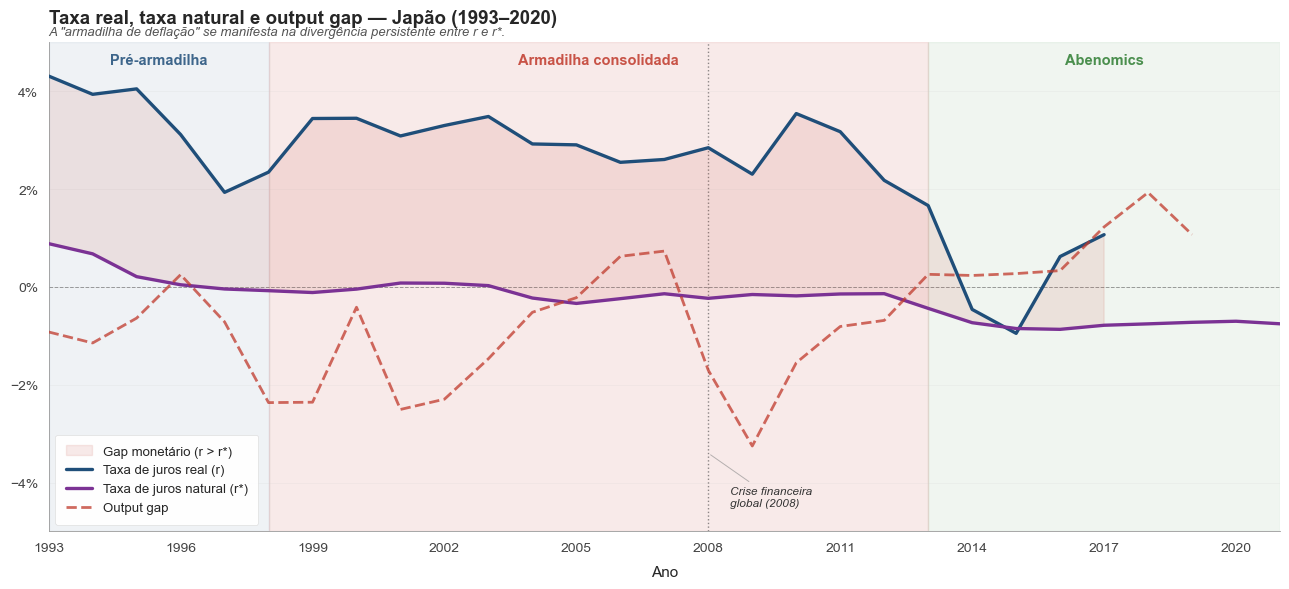

In [5]:


# Estilo geral

#Define o tema do Seaborn sem linhas de grade
sns.set_style('white')

#Customiza o tamanho das fontes e elementos do gráfico
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

#Garantindo que os valores dda coluna Year são do tipo int
japao_final['Year'] = japao_final['Year'].astype(int)
tx_n_y['Year']      = tx_n_y['Year'].astype(int)
gap_ano['Year']     = gap_ano['Year'].astype(int)

# Paleta 
COR_REAL    = '#1f4e79'  
COR_NATURAL = '#7b3294'   
COR_GAP     = '#c0392b'   

# Criando do gráfico

#Cria a figura e os eixos definindo o tamanho da imagem (Proporção 13,6)
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white') #Fundo branco

# Sombreamento dos três períodos
ax.axvspan(1993, 1998, alpha=0.07, color=COR_REAL,    zorder=0)
ax.axvspan(1998, 2013, alpha=0.10, color=COR_GAP,     zorder=0)
ax.axvspan(2013, 2021, alpha=0.07, color='#2e7d32',   zorder=0)

# Limites e rótulos dos períodos
ax.set_ylim(-5, 5)
ax.set_xlim(1993, 2021)

#Adiciona os rótulos de texto centralizados no topo de cada período
y_label = 4.55
ax.text(1995.5, y_label, 'Pré-armadilha',
        ha='center', fontsize=10.5, color=COR_REAL, weight='bold', alpha=0.85)
ax.text(2005.5, y_label, 'Armadilha consolidada',
        ha='center', fontsize=10.5, color=COR_GAP, weight='bold', alpha=0.85)
ax.text(2017, y_label, 'Abenomics',
        ha='center', fontsize=10.5, color='#2e7d32', weight='bold', alpha=0.85)

# Linha do zero
ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)

# Plotagem dos dados

#Faz o merge dos dados para cruzar os anos e preencher a área de gap
txs_junts = japao_final.merge(tx_n_y, on='Year', how='inner')

# Preenche com cor a área entre as taxas de juros(r e r*)
ax.fill_between(txs_junts['Year'],
                txs_junts['Taxa de juros real'],
                txs_junts['Natural interest rate'],
                where=(txs_junts['Taxa de juros real'] > txs_junts['Natural interest rate']),
                color=COR_GAP, alpha=0.10, interpolate=True, zorder=2,
                label='Gap monetário (r > r*)')

# Plotagem das linhas principais 

#L1 = Taxa de juros real(r)
sns.lineplot(data=japao_final, x='Year', y='Taxa de juros real',
             label='Taxa de juros real (r)',
             linewidth=2.4, color=COR_REAL, ax=ax, zorder=3)

#L2 = Taxa de juros natural (r*)
sns.lineplot(data=tx_n_y, x='Year', y='Natural interest rate',
             label='Taxa de juros natural (r*)',
             linewidth=2.4, color=COR_NATURAL, ax=ax, zorder=3)

#L3 = Output Gap
sns.lineplot(data=gap_ano, x='Year', y='Output gap',
             label='Output gap',
             linewidth=2.0, color=COR_GAP, alpha=0.75,
             linestyle='--', ax=ax, zorder=3)


#Formatação dos eixos

# Eixo Y em formato de porcentagem
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Define a escala do eixo X para saltar de 3 em 3 anos
ax.set_xticks(range(1993, 2022, 3))

# Título dos eixos e título principal
ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('', fontsize=11) #eixo y sem título pois estamos plotando 3 variáveis
ax.set_title('Taxa real, taxa natural e output gap — Japão (1993–2020)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

# Adiciona subtítulo 
ax.text(0.0, 1.015,
        'A "armadilha de deflação" se manifesta na divergência persistente entre r e r*.',
        transform=ax.transAxes, fontsize=9.5, style='italic',
        color='#555', ha='left')

# Legenda mais limpa
legend = ax.legend(loc='lower left', framealpha=0.95, fontsize=9.5,
                   frameon=True, edgecolor='#ddd', borderpad=0.8)
#Espessura da borda da legenda
legend.get_frame().set_linewidth(0.5)

# Ativa apenas as linhas de grade horizontais (Eixo Y)
ax.grid(axis='y', alpha=0.22, linewidth=0.5)
#Garante que as linhas de grade verticais fiquem ocultas
ax.grid(axis='x', visible=False)

# Remove as bordas superior e da direita 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#Customiza as bordas esquerda e inferior na cor cinza
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

# Faz com que os tracinhos dos eixos (ticks) fiquem mais discretos
ax.tick_params(colors='#444', length=4, width=0.6)

# Marcador da crise financeira global de 2008

#Desenha a linha vertical pontilhada 
ax.axvline(2008, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)

#Adiciona o texto explicativo
ax.annotate('Crise financeira\nglobal (2008)',
            xy=(2008, -3.4), xytext=(2008.5, -4.3),
            fontsize=8.5, ha='left', va='center',
            color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))

#Ajusta automaticamente o espaçamento dos elementos para evitar cortes nas bordas
plt.tight_layout()

#Salva o gráfico no diretório especificado
plt.savefig(FIGURAS/'juros_e_gap_japao.png', dpi=200,
            bbox_inches='tight', facecolor='white')


plt.show()

